# Extreme Correction 

In [1]:
import xarray as xr

In [2]:
historical_dataset = xr.open_dataset("inputs/Wave_families_santona_daily.nc")
sampled_dataset = xr.open_dataset("inputs/simulated_waves_100years.nc").rename({"bulk_Hs": "Hs", "bulk_Tp": "Tp", "bulk_Dir": "Dir"})

In [3]:
historical_dataset

<xarray.Dataset> Size: 935kB
Dimensions:      (time: 14610)
Coordinates:
  * time         (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
Data variables:
    sea_Hs       (time) float32 58kB ...
    sea_Tp       (time) float32 58kB ...
    sea_Dir      (time) float32 58kB ...
    swell_1_Hs   (time) float64 117kB ...
    swell_1_Tp   (time) float64 117kB ...
    swell_1_Dir  (time) float64 117kB ...
    Hs           (time) float32 58kB ...
    Tp           (time) float32 58kB ...
    Dir          (time) float32 58kB ...
    bmus         (time) int64 117kB ...

In [4]:
sampled_dataset

<xarray.Dataset> Size: 117MB
Dimensions:  (n_sim: 100, time: 36525)
Coordinates:
  * time     (time) datetime64[ns] 292kB 2000-01-01 2000-01-02 ... 2099-12-31
Dimensions without coordinates: n_sim
Data variables:
    DWT      (n_sim, time) int64 29MB ...
    Hs       (n_sim, time) float64 29MB ...
    Tp       (n_sim, time) float64 29MB ...
    Dir      (n_sim, time) float64 29MB ...

In [5]:
from bluemath_tk.distributions.extreme_correction import ExtremeCorrection

In [6]:
config = {
    "var": "Hs",
    "bmus": [False, ""],
    "join_sims": True,
    "folder": None,
}

pot_config = {
    "init_threshold": 0.01,
    "n0": 10,
    "min_peak_distance": 2,
    "sig_level": 0.05,
    "plot": False,
}

In [7]:
extr_corr = ExtremeCorrection(
    corr_config=config,
    pot_config=pot_config,
    method="pot" # "pot" for GPD or "am" for GEV
)

In [8]:
extr_corr.fit(data_hist=historical_dataset, plot_diagnostic=False)

In [9]:
sim_pit_data_corrected = extr_corr.transform(data_sim=sampled_dataset, prob="unif", random_state=0)

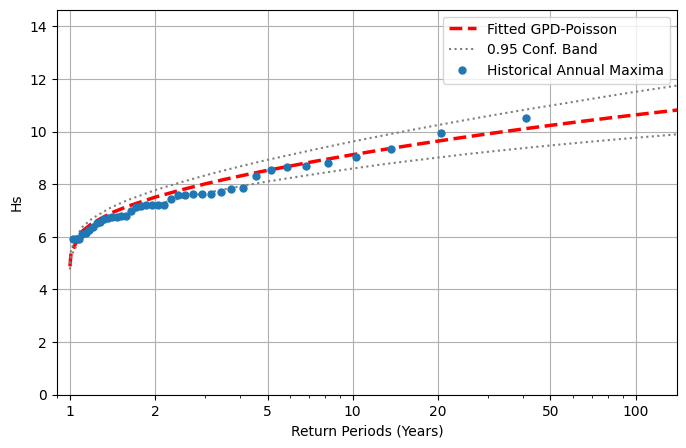

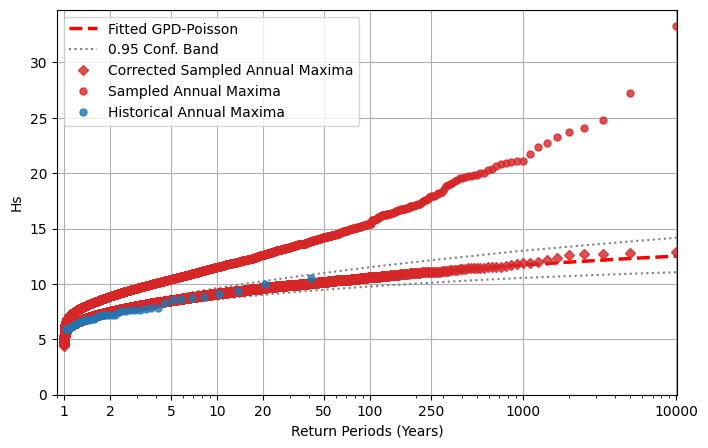

In [10]:
figs, axes = extr_corr.plot()

In [11]:
sim_pit_data_corrected

<xarray.Dataset> Size: 146MB
Dimensions:  (n_sim: 100, time: 36525)
Coordinates:
  * time     (time) datetime64[ns] 292kB 2000-01-01 2000-01-02 ... 2099-12-31
Dimensions without coordinates: n_sim
Data variables:
    DWT      (n_sim, time) int64 29MB ...
    Hs       (n_sim, time) float64 29MB ...
    Tp       (n_sim, time) float64 29MB ...
    Dir      (n_sim, time) float64 29MB ...
    Hs_corr  (n_sim, time) float64 29MB 1.618 1.302 1.599 ... 2.251 2.177 0.9566

In [12]:
sim_pit_data_corrected = extr_corr.fit_transform(
    data_hist=historical_dataset,
    data_sim=sampled_dataset,
    prob="unif",
    plot_diagnostic=False
)

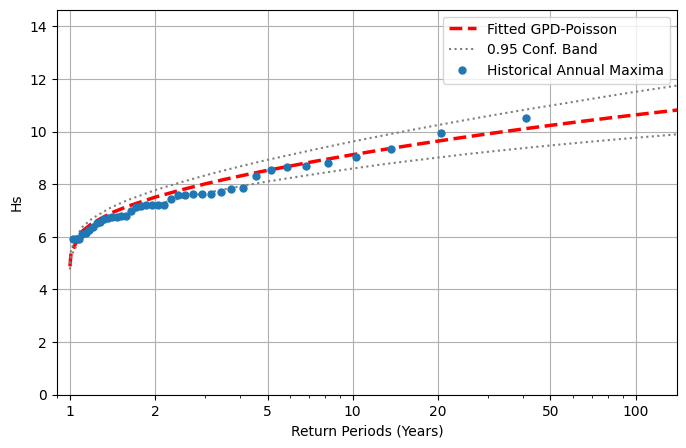

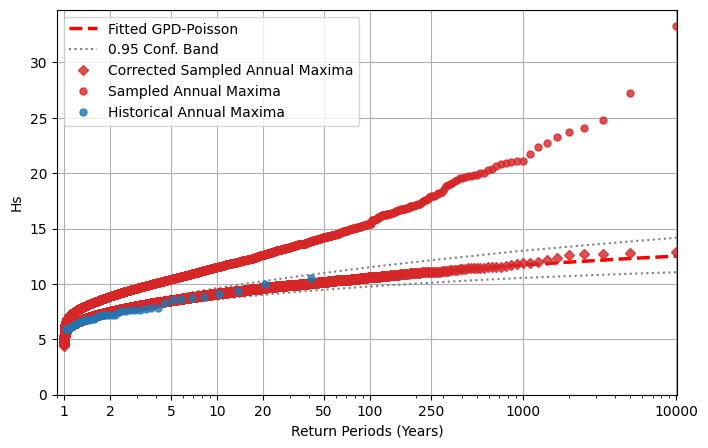

In [13]:
figs, axes = extr_corr.plot()